##### SVD應用：影像壓縮

右上角可以下載（snoopy.png也要下載）

如果沒有寫程式的環境可以使用google colab，把載好的檔案上傳到google drive就可以跑了。

檔案也放在雲端方便下載：
https://drive.google.com/drive/folders/14uvdmHHpIhTuaD2Xovc0Q4bJFPkxtJvc

但請不要在我的google drive那邊直接跑，那邊是共用的，一樣先複製到自己的雲端再跑。

---

載入套件：
- numpy 數學工具
- matplotlib.pyplot 繪圖工具
- matplotlib.image.imread 讀圖片用

正常圖片不會是正方形的（方陣），`square_matrix = True` 會先把圖片裁切成正方形，若要跑原本非正方形的圖片改 `square_matrix = False`。

`DPI` 設定畫素，可以不用理它

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread

square_matrix = True # change to False for non-square image
DPI = 100

讀取並印出圖片，一般圖片的結構會是長x寬x色彩（RGB）

比如說範例圖片為長：1021、寬：1600、RGB：3

RGB image size: (1021, 1600, 3)
squared image size: (1021, 1021, 3)


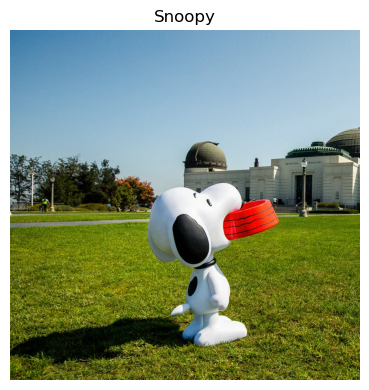

In [2]:
imgRGB = imread("snoopy.png")
print("RGB image size:", imgRGB.shape)

if square_matrix:
    square_size = min(imgRGB.shape[0], imgRGB.shape[1])
    imgRGB = imgRGB[:, :square_size, :]
    print("squared image size:", imgRGB.shape)

fig, ax = plt.subplots(1 ,figsize=(4, 4), dpi=DPI)
ax.imshow(imgRGB)
ax.set_title("Snoopy")
ax.axis("off")
plt.tight_layout()
plt.show()

只考慮單色灰階，取RGB平均

沿著最後一個維度取平均：`np.mean(imgRGB, axis=-1)`

以方陣為例，目前圖片共用了長x寬 = 1021 x 1021 = 1042441個儲存量，**我們希望透過SVD減少儲存量**

gray scale image size: (1021, 1021)


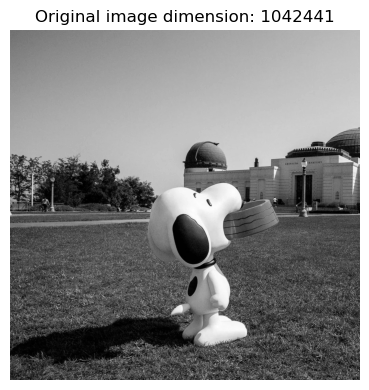

In [3]:
imgGrayScale = np.mean(imgRGB, axis=-1)
img_size = imgGrayScale.shape
img_dim = img_size[0]*img_size[1]
print("gray scale image size:", img_size)

fig, ax = plt.subplots(1 ,figsize=(4, 4), dpi=DPI)
ax.imshow(imgGrayScale, cmap="gray")
ax.set_title("Original image dimension: {}".format(img_dim))
ax.axis("off")
plt.tight_layout()
plt.show()

使用numpy內建SVD `np.linalg.svd(imgGrayScale, full_matrices=False)` 簡單看一下結果

以方陣為例：

$$
\text{imgGrayScale} = UDV^\top
$$
where $U\in\mathbb{R}^{1021\times1021}$, $D\in\mathbb{R}^{1021\times1021}$, $V^\top\in\mathbb{R}^{1021\times1021}$

- numpy內建SVD給的 `d` 為$D$的對角元素組成的向量，可通過 `np.diag(d)` 得到$D$
- numpy內建SVD給的 `V` 是上面公式的$V^\top$，要注意是已經轉置過的

In [4]:
U, d, V = np.linalg.svd(imgGrayScale, full_matrices=False)
D = np.diag(d)
print("matrix U size:", U.shape)
print(np.round(U, 2))
print("\nmatrix D size:", D.shape)
print(np.round(D, 2))
print("\nmatrix V size:", V.shape)
print(np.round(V, 2))

matrix U size: (1021, 1021)
[[-0.04 -0.01  0.02 ... -0.   -0.01 -0.04]
 [-0.04 -0.01  0.02 ... -0.05  0.05  0.03]
 [-0.04 -0.01  0.02 ...  0.04 -0.01 -0.04]
 ...
 [-0.02 -0.01  0.01 ...  0.   -0.    0.  ]
 [-0.02 -0.01  0.01 ...  0.    0.   -0.  ]
 [-0.02 -0.    0.01 ...  0.   -0.    0.  ]]

matrix D size: (1021, 1021)
[[507.81   0.     0.   ...   0.     0.     0.  ]
 [  0.    93.59   0.   ...   0.     0.     0.  ]
 [  0.     0.    60.25 ...   0.     0.     0.  ]
 ...
 [  0.     0.     0.   ...   0.     0.     0.  ]
 [  0.     0.     0.   ...   0.     0.     0.  ]
 [  0.     0.     0.   ...   0.     0.     0.  ]]

matrix V size: (1021, 1021)
[[-0.03 -0.03 -0.03 ... -0.03 -0.03 -0.03]
 [ 0.01  0.    0.   ... -0.01 -0.01 -0.01]
 [-0.01 -0.01 -0.01 ...  0.03  0.03  0.03]
 ...
 [-0.01  0.01 -0.   ...  0.03 -0.04  0.04]
 [-0.01  0.01  0.01 ... -0.02  0.    0.  ]
 [-0.02  0.02 -0.01 ...  0.    0.01 -0.  ]]


In [5]:
def memoryUsage(U, d, V):
    ''' Compute the memory usage of SVD's matrices.

        Inputs (square matrix case)
        U: n x k matrix
        d: k x 1 vector
        V: k x n matrix

        Note that since D is a diagonal matrix, 
        we store it by the vector of its diagonal elements (size k instead of k x k) '''
    return U.shape[0]*U.shape[1] + d.shape[0] + V.shape[0]*V.shape[1]

我們先簡單驗證把$U,D,V^\top$乘回去可以得到原本的圖片。

- `@` 為numpy裡的矩陣乘法

函式 `memoryUsage` 計算$U,D,V^\top$總共需要的儲存量，將原本的灰階圖片（1042441）用$U,D,V^\top$儲存（2085903）會提升儲存量。

- 注意在算$D$的儲存量時，因為他是對角矩陣$(\mathbb{R}^{1021\times1021})$我們只要存元素為對角元素的一個向量$(\mathbb{R}^{1021})$就好。

不過一個圖片的矩陣裡可能有很多不必要的資訊，接下來我們會看**如何利用SVD篩選重要資訊**。

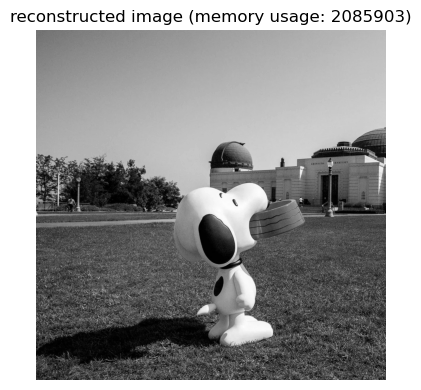

In [6]:
imgReconstruct = U@D@V
imgReconstructUsage = memoryUsage(U, d, V)

fig, ax = plt.subplots(1 ,figsize=(4, 4), dpi=DPI)
ax.imshow(imgReconstruct, cmap="gray")
ax.set_title("reconstructed image (memory usage: {})".format(imgReconstructUsage))
ax.axis("off")
plt.tight_layout()
plt.show()

SVD的對角矩陣$D$從左上到右下會從大到小排，$D_{ii}$的值在影像裡簡單來說會是對應$U$第$i$個row跟$V^\top$第$i$個column儲存資訊的重要程度。

比如這邊我們取前10重要：

- 取$U$前10個row：$U_{10}\in\mathbb{R}^{1021\times10}$
- 取$D$前10個對角元素：$D_{10}\in\mathbb{R}^{10\times10}$
- 取$V^\top$前10個column：$V^\top_{10}\in\mathbb{R}^{10\times1021}$

In [7]:
k = 10

d_k = d[:k]
U_k = U[:, :k]
V_k = V[:k, :]
D_k = np.diag(d_k)

print("matrix U size:", U_k.shape)
print(np.round(U_k, 2))
print("\nmatrix D size:", D_k.shape)
print(np.round(D_k, 2))
print("\nmatrix V size:", V_k.shape)
print(np.round(V_k, 2))

matrix U size: (1021, 10)
[[-0.04 -0.01  0.02 ... -0.    0.    0.  ]
 [-0.04 -0.01  0.02 ... -0.    0.   -0.  ]
 [-0.04 -0.01  0.02 ... -0.    0.   -0.  ]
 ...
 [-0.02 -0.01  0.01 ... -0.    0.    0.  ]
 [-0.02 -0.01  0.01 ... -0.01 -0.01  0.01]
 [-0.02 -0.    0.01 ... -0.01 -0.    0.01]]

matrix D size: (10, 10)
[[507.81   0.     0.     0.     0.     0.     0.     0.     0.     0.  ]
 [  0.    93.59   0.     0.     0.     0.     0.     0.     0.     0.  ]
 [  0.     0.    60.25   0.     0.     0.     0.     0.     0.     0.  ]
 [  0.     0.     0.    56.24   0.     0.     0.     0.     0.     0.  ]
 [  0.     0.     0.     0.    41.97   0.     0.     0.     0.     0.  ]
 [  0.     0.     0.     0.     0.    40.82   0.     0.     0.     0.  ]
 [  0.     0.     0.     0.     0.     0.    28.18   0.     0.     0.  ]
 [  0.     0.     0.     0.     0.     0.     0.    23.55   0.     0.  ]
 [  0.     0.     0.     0.     0.     0.     0.     0.    21.87   0.  ]
 [  0.     0.     0.     0. 

In [8]:
def compressRatio(original_usage, compressed_usage):
    ''' Compute the compress ratio (percentage) '''
    return 100*(compressed_usage/original_usage)

一樣將$U_{10},D_{10},V_{10}^\top$乘回去得到**只用前10重要的資訊**的圖片。

$$
\text{imgCompress} = U_{10}D_{10}V_{10}^\top
$$

此時$U_{10},D_{10},V_{10}^\top$的 `memoryUsage` 會是$1021\times10+10+10\times1021=20430$，跟原圖片（1042441）比起來大幅減少儲存量。

函式 `compressRatio` 量化壓縮量：壓縮圖儲存量（20430）/ 原圖片（1042441) $\approx$ 2%

我們只用2%的儲存量就得到一個有點輪廓的圖片了，接著我們看要**如何決定取前幾重要的資訊**。

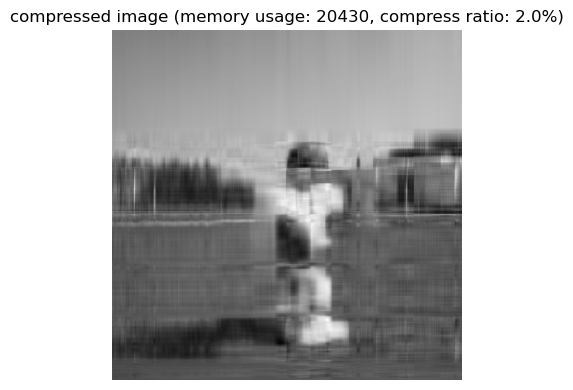

In [9]:
imgCompress = U_k@D_k@V_k
imgCompressUsage = memoryUsage(U_k, d_k, V_k)
imgCompressRatio = compressRatio(img_dim, imgCompressUsage)

fig, ax = plt.subplots(1 ,figsize=(4, 4), dpi=DPI)
ax.imshow(imgCompress, cmap="gray")
ax.set_title("compressed image (memory usage: {}, compress ratio: {:.1f}%)".format(imgCompressUsage, imgCompressRatio))
ax.axis("off")
plt.tight_layout()
plt.show()

我們將對角矩陣$D$的值畫出來，會發現大約400項以後的都很接近0，也就是400後的幾乎不重要了。

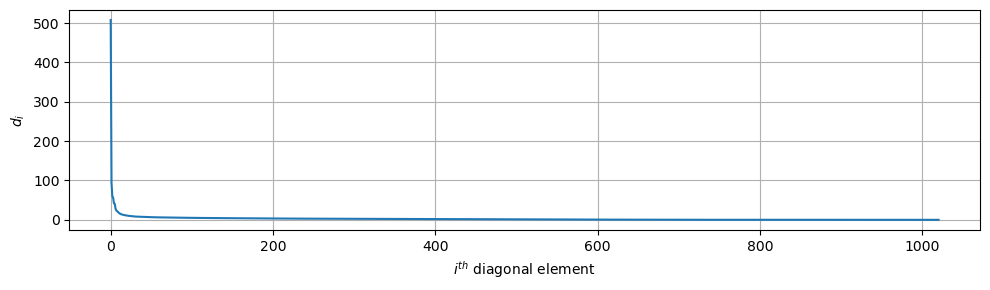

In [10]:
fig, ax = plt.subplots(1 ,figsize=(10, 3), dpi=DPI)
ax.plot(d)
ax.set_xlabel("$i^{th}$ diagonal element")
ax.set_ylabel("$d_i$")
ax.grid("on")
plt.tight_layout()
plt.show()

接著我們畫cumulative sum的圖，如果將$\sum_id_{ii}$視為總資訊量，會發現大約前400項就佔9成以上的資訊量了。

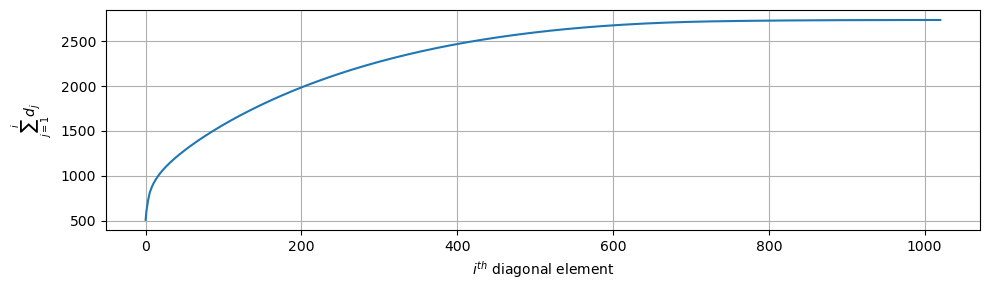

In [11]:
fig, ax = plt.subplots(1 ,figsize=(10, 3), dpi=DPI)
ax.plot(np.cumsum(d))
ax.set_xlabel("$i^{th}$ diagonal element")
ax.set_ylabel("$\sum_{j=1}^i d_j$")
ax.grid("on")
plt.tight_layout()
plt.show()

依據上述觀察，我們分別觀察取前10、100、400、500項看其圖片與壓縮量：

- $k=10$ 只用了約2%儲存量，但圖片只看得出大概輪廓
- $k=100$ 用了約20%儲存量，圖片有一些噪音
- $k=400$ 用了約80%儲存量，圖片接近原圖
- $k=500$ 用了約100%儲存量，圖片接近原圖，已經跟前面看不出太大差異，也已經快用超過原圖的儲存量了

找出適合的$k$值可以有效降低圖片儲存量並保留圖片特徵，在影像處理領域有很多應用。

最後大家可以把一開始 `square_matrix = True` 改成 `square_matrix = False` 觀察非方陣的時候SVD長什麼樣子～


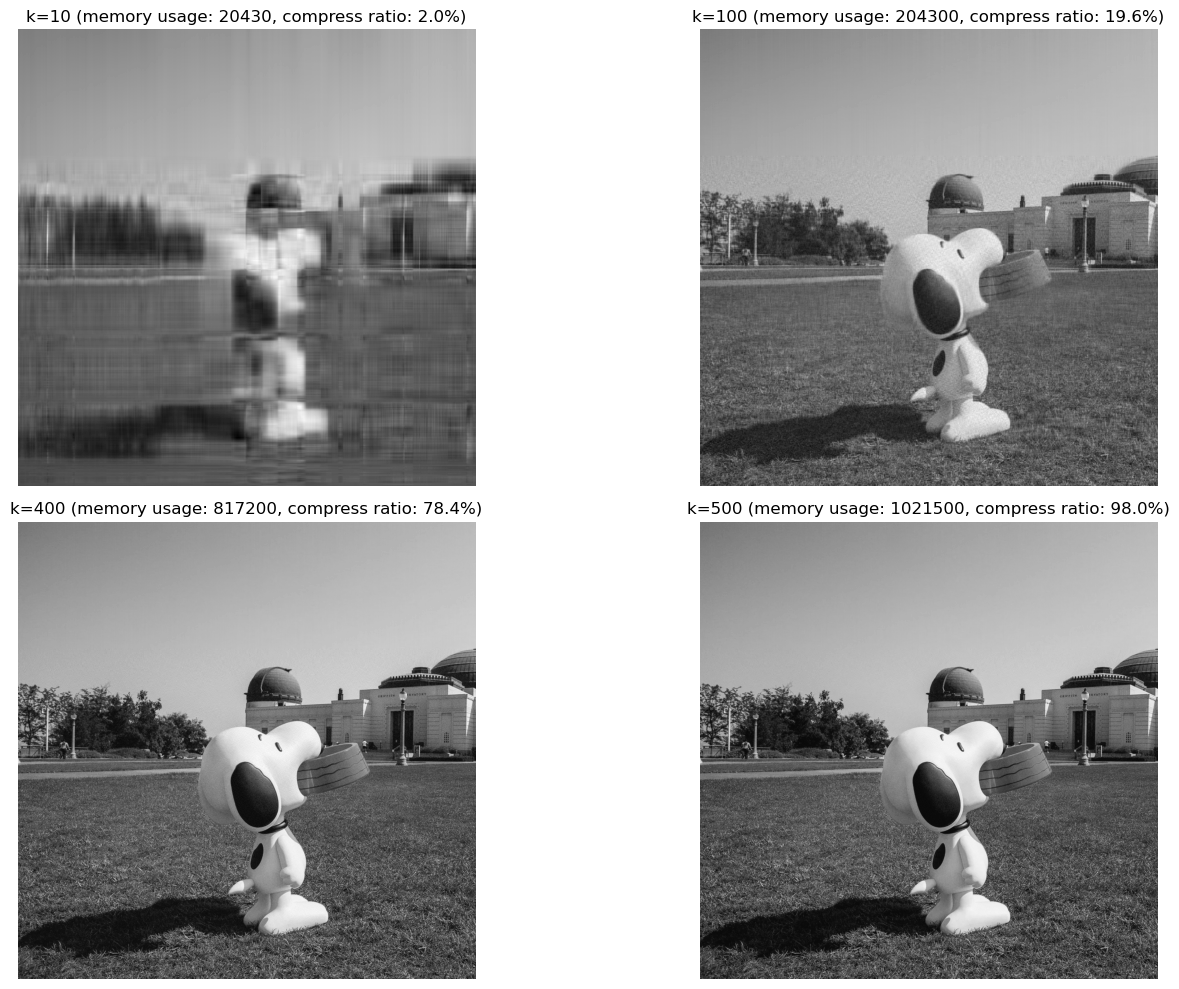

In [12]:
k_list = [10, 100, 400, 500]

fig, ax = plt.subplots(2,2, figsize=(16,10), dpi=DPI)
ax = ax.flatten()
i = 0
for i, k in enumerate(k_list):
    d_k = d[:k]
    U_k = U[:, :k]
    V_k = V[:k, :]
    img_k = U_k@np.diag(d_k)@V_k
    img_kUsage = memoryUsage(U_k, d_k, V_k)
    img_kRatio = compressRatio(img_dim, img_kUsage)
    
    ax[i].imshow(img_k ,cmap="gray")
    ax[i].axis("off")
    ax[i].set_title("k={} (memory usage: {}, compress ratio: {:.1f}%)".format(k, img_kUsage, img_kRatio))
    
plt.tight_layout()
plt.show()